In [ ]:
#run this cell only if using files from drive
'''
Access to our repository on drive:

https://drive.google.com/drive/folders/1GChjVnkv11-5cJDNLoe3tGKgmOvhTdNX?usp=drive_link
'''
from google.colab import drive
drive.mount('/content/drive')

# Project 1: Explainable AI in a Radiology Scenario

This notebook implements **Explainable AI (XAI)** techniques for medical imaging, specifically **chest X-ray classification** using a DenseNet model.

We will:
- **Preprocess** X-ray images
- **Train a Deep Learning model**
- **Evaluate model performance**
- **Apply Explainability techniques** (e.g., Grad-CAM, Integrated Gradients)
- **Assess explanation quality** using **Quantus** library.

### **Setup & Dependencies**

Ensuring **reproducibility**: We install required packages and **instantiate all package versions**.

In [ ]:
# Essential installations
%pip install tensorflow
%pip install tf-keras-vis
%pip install tf-explain
%pip install matplotlib pillow
%pip install quantus

In [ ]:
# Core deep learning
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# tf-keras-vis for saliency maps
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize
from tf_keras_vis.utils.scores import CategoricalScore

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import patches

# For handling images
import numpy as np
import io
from PIL import Image as PILImage
import os
import pandas as pd
from skimage.segmentation import slic
import keras
import gc

#statistics
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ndcg_score
from scipy.stats import binomtest
import cv2
from scipy.spatial.distance import cosine

# explanations
import tf_explain
from tf_explain.core.grad_cam import GradCAM
from tf_explain.core.smoothgrad import SmoothGrad
from tf_explain.core.integrated_gradients import IntegratedGradients
import quantus
from quantus.metrics import PixelFlipping, LocalLipschitzEstimate, ModelParameterRandomisation, RelevanceMassAccuracy, Complexity

#
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"Matplotlib: {mpl.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {compute_class_weight.__module__.split('.')[0]} {compute_class_weight.__module__.split('.')[1]}")
print(f"tf-keras-vis: {Saliency.__module__.split('.')[0]} {Saliency.__module__.split('.')[1]}")
print(f"Quantus: {quantus.__version__}")

## **Part 1: Data Acquisition and Preprocessing**

This section handles:

- **Downloading dataset** (from Kaggle) (if necessary)
- **Preprocessing images** (resizing, normalizing,...)
- Splitting data into **training & validation sets**
- Loading cleaned **frontal images only**

In [ ]:
IMG_SIZE = (224, 224)  # Standard size for input images
BATCH_SIZE = 16        # Number of samples per batch
EPOCHS = 10            # Number of training epochs
DOWNLOAD_DATA = False
pre_trained_model_available = True #False
# OUTPUT_DIR = "/content/drive/MyDrive/XAI_Group4/"
BASE_DIR = "/content/drive/MyDrive/XAI_Group4/"
CLEAN_DIR_k = os.path.join(BASE_DIR, "CheXpert-v1.0-small", "frontal_resized_k")
CLEAN_DIR = os.path.join(BASE_DIR, "frontal_resized")
OUTPUT_MODEL_PATH = os.path.join(BASE_DIR, "best_densenet169_softmax.keras")

### **1a) Data from kaggle**

In [ ]:
def get_data_from_kaggle(output_path):
    # Directory where the dataset is located (downloaded from Kaggle)
    input_dir = kagglehub.dataset_download("ashery/chexpert")
    os.makedirs(output_path, exist_ok=True)

    # Traverse through the dataset and process images and CSV files
    for dirpath, _, files in os.walk(input_dir):
        for file in files:
            input_image_path = os.path.join(dirpath, file)
            relative_path = os.path.relpath(input_image_path, input_dir)
            output_image_path = os.path.join(output_path, relative_path)
            os.makedirs(os.path.dirname(output_image_path), exist_ok=True)

            # Process image files
            if file.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                preprocess_image(input_image_path, output_image_path)
            # Copy CSV files
            if file.endswith('.csv'):
                csv = pd.read_csv(os.path.join(dirpath, file))
                csv.to_csv(os.path.join(output_path, file), index=False)

    print(f"All images resized and saved in: {output_path}")

In [ ]:
if DOWNLOAD_DATA:
  get_data_from_kaggle(BASE_DIR)

### **1b) Image Preprocessing Function**  
This function **reads, decodes, resizes, and normalizes** images to ensure they are in a consistent format for model training. It also includes **error handling** to replace missing or corrupted images with a blank placeholder, preventing disruptions in data loading. This step ensures **robustness and consistency** in the input pipeline.  

In [ ]:
def preprocess_image(path, label):
    try:
        image = tf.io.read_file(path)
        image = tf.io.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label
    except (tf.errors.NotFoundError, tf.errors.DataLossError):
        print(f"Warning: Missing or corrupt file {path.numpy().decode()}. Replacing with blank image.")
        return tf.zeros((224, 224, 3), dtype=tf.float32), label

### **1c) Batch Image Preprocessing**  
This function **automates the preprocessing of all frontal X-ray images**, ensuring they are resized and normalized before training. It **processes images in batches** to handle large datasets efficiently, skipping corrupted files to maintain data integrity. The processed images are saved in a cleaned dataset folder for **faster and more stable model training**.  

This step is not necessary

In [ ]:
# Batch preprocessing - clean all frontal images and save to cleaned_train folder
def batch_preprocess_images():
    source_folder = os.path.join(CLEAN_DIR, "train")
    destination_folder = os.path.join(CLEAN_DIR, "cleaned_train")
    os.makedirs(destination_folder, exist_ok=True)

    batch_size = 10000
    image_paths = []

    # Collect all frontal images
    for root, _, files in os.walk(source_folder):
        for file in files:
            if "_frontal" in file.lower():
                file_path = os.path.join(root, file)
                image_paths.append(file_path)

    total_batches = (len(image_paths) + batch_size - 1) // batch_size

    for batch_idx in range(total_batches):
        batch = image_paths[batch_idx * batch_size:(batch_idx + 1) * batch_size]
        print(f"Processing batch {batch_idx + 1}/{total_batches}...")

        for file_path in tqdm(batch, desc=f"Batch {batch_idx + 1}/{total_batches}"):
            try:
                img = cv2.imread(file_path)
                if img is None:
                    print(f"Skipping missing/corrupt file: {file_path}")
                    continue

                img_resized = cv2.resize(img, IMG_SIZE)
                img_resized = img_resized.astype(np.float32) / 255.0

                relative_path = os.path.relpath(file_path, source_folder)
                save_path = os.path.join(destination_folder, relative_path)

                os.makedirs(os.path.dirname(save_path), exist_ok=True)
                cv2.imwrite(save_path, (img_resized * 255).astype(np.uint8))

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                continue

        gc.collect()

    print(f"Preprocessing complete. Processed images saved to: {destination_folder}")

def preprocess_with_py_function(path, label):
    image, label = tf.py_function(preprocess_image, [path, label], [tf.float32, tf.float32])
    image.set_shape((224, 224, 3))
    return image, label

### **1d) Creating & Loading Datasets**  
This function **efficiently processes image data using TensorFlow tensors**, avoiding computational issues with NumPy arrays. It converts image paths and labels into a **TensorFlow dataset pipeline**, applying **caching, shuffling, batching, and prefetching** for optimized training. Additionally, it filters the dataset to include **only frontal X-rays** with valid labels for pleural effusion.

In [ ]:
#function that doesn't use the np.array but tensor flow to process the data for densenet
#it creates less problems as computational problems
def create_dataset(image_paths, labels, is_training=True):
    processed_image_paths = [os.path.join(BASE_DIR, path) for path in image_paths]

    image_paths_tensor = tf.convert_to_tensor(processed_image_paths, dtype=tf.string)
    labels_tensor = tf.convert_to_tensor(labels, dtype=tf.float32)
    dataset = tf.data.Dataset.from_tensor_slices((image_paths_tensor, labels_tensor))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.cache().shuffle(buffer_size=1000)
    else:
        dataset = dataset.cache()

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    dataset = dataset.ignore_errors()
    return dataset

In [ ]:
def load_and_filter_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["Frontal/Lateral"] == "Frontal"]
    df = df[df["Pleural Effusion"].notna()]
    df = df[df["Pleural Effusion"] != -1.0]
    df.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)
    return df.sort_values(by='ID')

In [ ]:
os.path.exists(CLEAN_DIR_k)

True

In [ ]:
os.path.join(CLEAN_DIR, "train.csv")

'/content/drive/MyDrive/XAI_Group4/frontal_resized/train.csv'

In [ ]:
if os.path.exists(CLEAN_DIR_k) and len(os.listdir(CLEAN_DIR_k)) > 0:
    print(f"Using preprocessed images from {CLEAN_DIR_k}.")
else:
    print("Preprocessed images not found. Running batch_preprocess_images()...")
    batch_preprocess_images()  # Run preprocessing
    CLEAN_DIR = os.path.join(BASE_DIR, "frontal_resized")

train_csv = os.path.join(CLEAN_DIR, "train.csv")
valid_csv = os.path.join(CLEAN_DIR, "valid.csv")

df_train = load_and_filter_data(train_csv)
df_valid = load_and_filter_data(valid_csv)

X = df_train.drop(columns=['Pleural Effusion'])
y = df_train['Pleural Effusion'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Using preprocessed images from /content/drive/MyDrive/XAI_Group4/CheXpert-v1.0-small/frontal_resized_k.


In [ ]:
x_valid = df_valid.drop('Pleural Effusion', axis=1)
y_valid = df_valid['Pleural Effusion']
valid_image_paths = x_valid['Path'].values
valid_labels = y_valid.values
valid_dataset = create_dataset(valid_image_paths, valid_labels, is_training=False)

## **Part 2: CNN**

### **2a) Model Training**

We use **DenseNet169**, a pre-trained model, to classify X-rays.

Why DenseNet? Dense connections improve feature reuse & gradient flow.
More informative explanations for medical images.

In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(zip(np.unique(y), class_weights))
print(f"Class weights: {class_weights}")

Class weights: {0: 2.0198031542748724, 1: 0.6644949869309094}


In [ ]:
def build_densenet169(input_shape=(224, 224, 3)):
    """ Build and compile a DenseNet169 model """
    base_model = DenseNet169(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dense(128, activation="relu")(x)
    x = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=x)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

    return model

In [ ]:
def train_densenet169(X_train, X_test, y_train, y_test, output_path, epochs=20, batch_size=16):
    train_dataset = create_dataset(X_train['Path'].values, y_train.values, is_training=True)
    val_dataset = create_dataset(X_test['Path'].values, y_test.values, is_training=False)

    model = build_densenet169()

    steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
    validation_steps = max(1, len(X_test) // BATCH_SIZE)

# print(f"Train Steps per Epoch: {steps_per_epoch}, Validation Steps: {validation_steps}")


    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        class_weight=class_weights
    )

    model.save("densenet169_pleural_effusion.h5")
    print("Model saved as 'densenet169_pleural_effusion.h5'.")
    return model, history

In [ ]:
train_dataset = create_dataset(X_train['Path'].values, y_train.values, is_training=True)
val_dataset = create_dataset(X_test['Path'].values, y_test.values, is_training=False)

In [ ]:
for image, label in train_dataset.take(1):
    print("Image shape:", image.shape)
    print("Label shape:", label.shape)

In [ ]:
steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
validation_steps = max(1, len(X_test) // BATCH_SIZE)

print(f"Train Steps per Epoch: {steps_per_epoch}, Validation Steps: {validation_steps}")

In [ ]:
if pre_trained_model_available:
    file_path = os.path.join(BASE_DIR, "weighteddensenet169_pleural_effusion.h5")
    model = load_model(file_path)
    model.summary()
    print("Model loaded successfully.")
else:
    model, history = train_densenet169(X_train, X_test, y_train, y_test, OUTPUT_MODEL_PATH, epochs=EPOCHS, batch_size=BATCH_SIZE)
    model.save(os.path.join(BASE_DIR, "weighteddensenet169_pleural_effusion1.h5"))
    history.to_csv(os.path.join(BASE_DIR, "densenet169_training_history.csv"), index=False)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 13,102,147 (49.98 MB)

 Trainable params: 459,265 (1.75 MB)

 Non-trainable params: 12,642,880 (48.23 MB)

 Optimizer params: 2 (12.00 B)

Model loaded successfully.


### **2b) Model evaluation**

After training, we evaluate the model:
- **accuracy**
- **precision**
- **recall**
- **F1-score**
- **ROC-AUC**

We also perfom a binomial test to show if the model is behaving good by chance or not.

In [ ]:
predictions = model.predict(valid_dataset)
predicted_classes = (predictions > 0.5).astype(int).flatten()

13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step


In [ ]:
print("Classification Report:\n", classification_report(valid_labels, predicted_classes))
print("Confusion Matrix:\n", confusion_matrix(valid_labels, predicted_classes))
# Binomial test for performance vs. random guessing (50%)
p_value_result = binomtest(
    sum(valid_labels == predicted_classes),
    n=len(valid_labels),
    p=0.5
)
print(f"P-Value from Binomial Test: {p_value_result.pvalue:.4e}")


Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.71      0.80       138
         1.0       0.58      0.86      0.69        64

    accuracy                           0.76       202
   macro avg       0.75      0.78      0.75       202
weighted avg       0.81      0.76      0.77       202

Confusion Matrix:
 [[98 40]
 [ 9 55]]
P-Value from Binomial Test: 1.1907e-13


In [ ]:
accuracy = accuracy_score(valid_labels, predicted_classes)
precision = precision_score(valid_labels, predicted_classes)
recall = recall_score(valid_labels, predicted_classes)
f1 = f1_score(valid_labels, predicted_classes)
roc_auc = roc_auc_score(valid_labels, predictions)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7574
Precision: 0.5789
Recall: 0.8594
F1 Score: 0.6918
ROC AUC: 0.8496


In [ ]:
loss, accuracy = model.evaluate(valid_dataset)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.7642 - loss: 0.5347
Validation Loss: 0.5367
Validation Accuracy: 0.7574


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


History loaded from file.


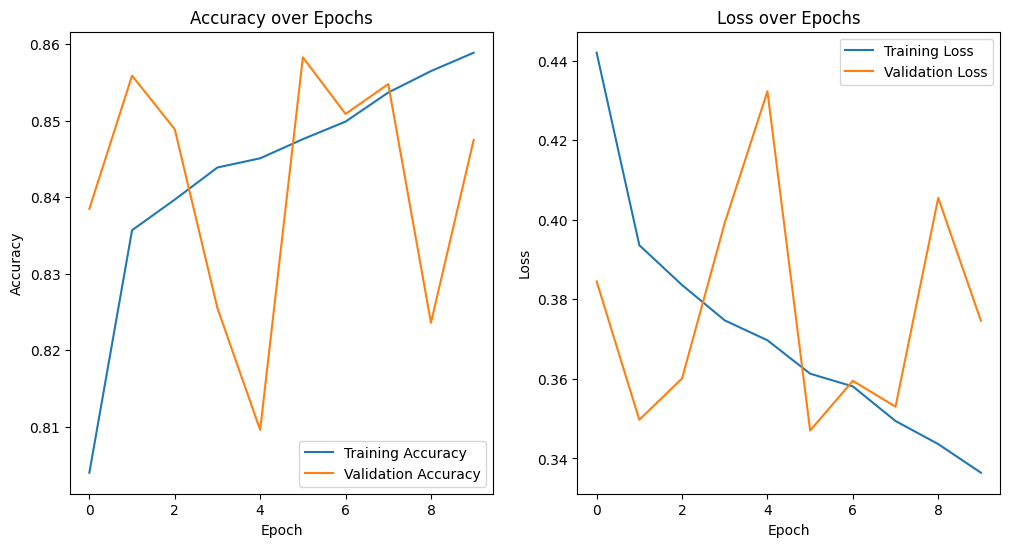

In [ ]:
def plot_training_history(history_dict):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 6))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_dict['accuracy'], label='Training Accuracy')
    plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history_dict['loss'], label='Training Loss')
    plt.plot(history_dict['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


if pre_trained_model_available:
    # Load saved history CSV file
    history_csv_path = os.path.join(BASE_DIR, "densenet169_training_log.csv")

    if os.path.exists(history_csv_path):
        history_df = pd.read_csv(history_csv_path)

        # Convert to dictionary to mimic Keras history object
        history_dict = {
            'accuracy': history_df['Accuracy'].tolist(),
            'val_accuracy': history_df['Val_Accuracy'].tolist(),
            'loss': history_df['Loss'].tolist(),
            'val_loss': history_df['Val_Loss'].tolist()
        }

        print("History loaded from file.")
        plot_training_history(history_dict)

    else:
        print(f"Warning: {history_csv_path} not found. Cannot plot history.")

else:
    # Directly use the history object from training
    if history:
        plot_training_history(history.history)
    else:
        print("Warning: No training history available.")


## **Part 3: Explainability Techniques**

###**3a) Saliency map implementation: Grad-CAM**

https://medium.com/@bijil.subhash/explainable-ai-saliency-maps-89098e230100

Visualizes **important image regions** that influenced the model’s decision.

why gradCAM: https://www.nature.com/articles/s42256-022-00536-x

implementation from:
https://www.analyticsvidhya.com/blog/2023/12/grad-cam-in-deep-learning/#h-implementation-of-grad-cam

In [ ]:
# please run this twice, it can happen that it provides a False result when instead is True. It might be a google Drive problem.
image_path = '/content/drive/MyDrive/XAI_Group4/CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg'
os.path.exists(image_path)

True

In [ ]:
def prep_single_image(image_path, model):
  img = load_img(image_path, target_size=(224, 224))
  img_array = img_to_array(img)  # np array (244, 244, 3)
  img_array = img_array.reshape((1,) + img_array.shape)  # shape (1, 244, 244, 3)

  return img, img_array


def plot_saliency_maps(images, sal_maps, image_names="", boundary_boxes=None, img_path=None):
    # Ensure inputs are lists
    if not isinstance(images, list):
      images = [images]
    if not isinstance(sal_maps, list):
      sal_maps = [sal_maps]
    if boundary_boxes is None:
      boundary_boxes = [None] * len(images)
    elif not isinstance(boundary_boxes, list):
      boundary_boxes = [boundary_boxes]
    if not isinstance(image_names, list):
      image_names = [image_names]

    num_images = len(images)
    fig, axes = plt.subplots(2, num_images, figsize=(4 * num_images, 8))

    if num_images == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i in range(num_images):
        sal_map = sal_maps[i]
        boundary_box = boundary_boxes[i]

        # Display the original image
        axes[0, i].imshow(img)
        axes[0, i].set_title("Original X-ray " + image_names[i])
        axes[0, i].axis('off')

        # Display the Saliency map
        axes[1, i].imshow(img, cmap="gray")  # Original image
        explan = axes[1, i].imshow(sal_map, cmap="seismic", alpha=0.5)
        axes[1, i].set_title("Explanation")
        axes[1, i].axis('off')

        if boundary_box:
            for bbox in boundary_box:
                x1, y1, x2, y2 = bbox
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='cyan', facecolor='none')
                axes[1, i].add_patch(rect)

    cbar = fig.colorbar(explan, ax=axes[1, -1], fraction=0.046, pad=0.04)
    cbar.set_label("Attribution Intensity")

    plt.tight_layout()

    if img_path:
        plt.savefig(img_path)

    plt.show()

This function is the custom explanation method using *GradCAM*.

In [ ]:
def custom_explain(model, inputs, targets, **kwargs):
    explanations = []
    for i in range(inputs.shape[0]):
      input_tensor = tf.convert_to_tensor(inputs[i:i+1], dtype=tf.float32)

      # Create gradient model
      grad_model = keras.models.Model(
            inputs=model.input,
            outputs=[model.get_layer("conv5_block32_concat").output, model.output]
      )

      with tf.GradientTape() as tape:
          last_conv_layer_output, preds = grad_model(input_tensor)
          class_channel = preds[:, 0]

      grads = tape.gradient(class_channel, last_conv_layer_output)
      pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

      # calculate heatmap
      last_conv_layer_output = last_conv_layer_output[0]
      heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
      heatmap = tf.squeeze(heatmap)

      # prepare for visualization
      heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
      heatmap = heatmap.numpy()
      heatmap = np.uint8(255 * heatmap)

      jet = mpl.colormaps["jet"]
      jet_colors = jet(np.arange(256))[:, :1]
      jet_heatmap = jet_colors[heatmap]

      # rgb colouring
      jet_heatmap = keras.utils.array_to_img(jet_heatmap)

      jet_heatmap = jet_heatmap.resize(IMG_SIZE)
      jet_heatmap = keras.utils.img_to_array(jet_heatmap)

      jet_heatmap = jet_heatmap.reshape(224, 224)
      explanations.append(jet_heatmap * 0.4)

    return np.array(explanations)

### **3b) Cosine Similarity Implementation**
Cosine similarity measures the **angle between feature vectors**, focusing on their **direction rather than magnitude**. This helps in identifying structurally similar X-rays even if brightness or scale varies.

In [ ]:
base_model = model
last_layer = base_model.get_layer('global_average_pooling2d')
model2 = Model(inputs=base_model.input, outputs=last_layer.output) #not anymore a classifier but a feature extractor

# Function to extract features using DenseNet and calculate cosine similarity
def calculate_feature_similarity(image_path1, image_path2, model):
    def preproces_image(image_path):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resize = tf.image.resize(img, (224,224))
        img_data = np.expand_dims(resize/(255), 0)
        return img_data

    img1 = preproces_image(image_path1)
    img2 = preproces_image(image_path2)

    features_img1 = model.predict(img1)
    features_img2 = model.predict(img2)

    # Flatten since DenseNet 'avg_pool' layer outputs (batch_size, 1024)
    features_img1 = features_img1.flatten()
    features_img2 = features_img2.flatten()

    # Compute cosine similarity
    similarity = 1 - cosine(features_img1, features_img2)

    return similarity

In [ ]:
def rank_images(query_image, dataset):
    # List to store tuples of (image, similarity score)
    similarity_scores = {}

    # Compute similarity for each image in the dataset
    for image in dataset:
        score = calculate_feature_similarity(query_image, image, model2)
        similarity_scores[image[-9:]] = score

    # Sort the images by score in descending order
    #ranked_images = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    return similarity_scores

# Example usage:
query_xray = '/content/drive/MyDrive/XAI_Group4/test_data/ranking_annotations/test_image.png'
xray_dataset = [os.path.join("/content/drive/MyDrive/XAI_Group4/test_data/ranking_annotations/", filename) for filename in os.listdir("/content/drive/MyDrive/XAI_Group4/test_data/ranking_annotations/") if filename.endswith(('.jpg', '.png'))]
ranked_list = rank_images(query_xray, xray_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


In [ ]:
ranked_list.pop('image.png')
print(ranked_list)

{'Rad_1.png': 0.8427786022264279, 'Rad_2.png': 0.8229131986983085, 'Rad_3.png': 0.8173771026899646, 'Rad_4.png': 0.8299246795135617, 'Rad_5.png': 0.7909631313672585, 'Rad_6.png': 0.8380099997221198, 'Rad_7.png': 0.762486516722717, 'Rad_8.png': 0.784673670216394, 'Rad_9.png': 0.7992027494323359, 'ad_10.png': 0.8067479166922323}


## **Part 4: Evaluating explanation methods**

### **4a) Testing Saliency Maps**  
To validate saliency maps, we compare them against **ground truth annotations** (e.g., bounding boxes) to check if highlighted regions align with medically relevant areas.


In [ ]:
# Load bounding box data
file_path = "/content/drive/MyDrive/XAI_Group4/test_data/Bounding-box annotations (320x320).xlsx"
df = pd.read_excel(file_path, sheet_name="Folha1")

# remove spaces in the csv entries
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
path_to_test_img = '/content/drive/MyDrive/XAI_Group4/test_data/ranking_annotations/'
output_folder = '/content/drive/MyDrive/XAI_Group4/saliency_maps_new/'

<ipython-input-53-7b78fdb59e0f>:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


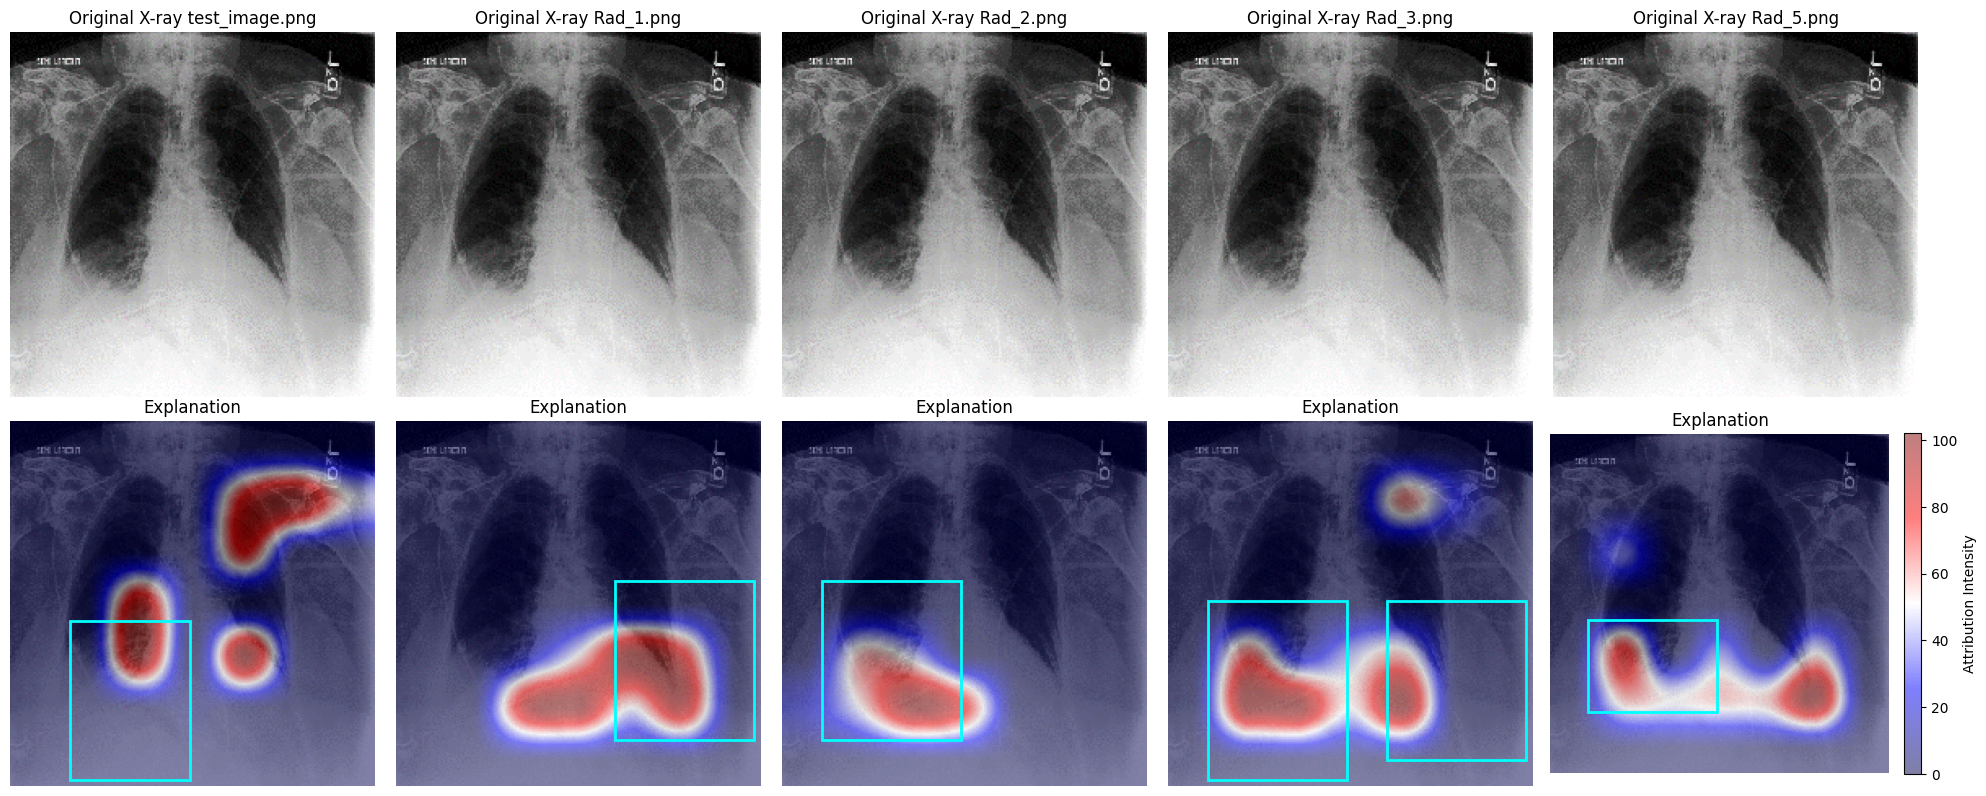

In [ ]:
img_list = []
sal_explanation_list = []
bboxes_list = []
image_names_list = []

for index, row in df.iterrows():
  image_name = row['Image']  + ".png"
  if image_name == 'Test':
    image_name = 'test_image.png'

  bboxes = []

  # extract bounding boxes into array
  for i in range(1, len(row) - 1, 4):
    if pd.notna(row.iloc[i]):
      x1 = (int(row.iloc[i])/320)*244
      y1 = (int(row.iloc[i + 1])/320)*244
      x2 = (int(row.iloc[i + 2])/320)*244
      y2 = (int(row.iloc[i + 3])/320)*244
      bboxes.append([x1, y1, x2, y2])

  img, img_array = prep_single_image(path_to_test_img + image_name, model)

  sal_explanations = custom_explain(model, img_array, None)

  bboxes_list.append(bboxes)
  img_list.append(img)
  sal_explanation_list.append(sal_explanations[0])
  image_names_list.append(image_name)

plot_saliency_maps(img_list, sal_explanation_list, image_names_list, bboxes_list, "/content/drive/MyDrive/XAI_Group4/grad_cam")

### **4b) Explanation Quality Assessment with Quantus**
Quantus is a toolkit for evaluating **XAI (Explainable AI) methods**, ensuring that model explanations are **trustworthy and robust**. It provides a set of metrics to assess different properties of explanations, such as **faithfulness, robustness, and complexity**. These metrics help in validating the reliability of explanations generated by methods like Grad-CAM and Integrated Gradients.

#### **Quantus Metrics:**
- **Faithfulness**: Measures how well explanations align with actual model decisions.
- **Robustness**: Assesses explanation stability under small perturbations.
- **Complexity**: Evaluates how interpretable or noisy an explanation is.
- **Localisation**: Checks if explanations highlight relevant image regions.
- **Randomisation Sensitivity**: Tests explanation changes with randomized model parameters.


In [ ]:
#This is for uploading a model that was trained earlier and saved.
m_path = os.path.join(BASE_DIR,'weighteddensenet169_pleural_effusion.h5')
model = load_model(m_path)

In [ ]:
# Load bounding box data
file_path = "/content/drive/MyDrive/XAI_Group4/test_data/Bounding-box annotations (320x320).xlsx"
df = pd.read_excel(file_path, sheet_name="Folha1")

# remove spaces in the csv entries
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
path_to_test_img = '/content/drive/MyDrive/XAI_Group4/test_data/ranking_annotations/'

x_batch = []
a_batch = []

for index, row in df.iterrows():
  image_name = row['Image']  + ".png"

  img, img_array = prep_single_image(path_to_test_img + image_name, model)
  x_batch.append(img_array)

  sal_explanations = custom_explain(model, img_array, None)
  a_batch.append(sal_explanations)

x_batch = np.concatenate(x_batch, axis=0)
x_batch= np.array(x_batch).astype(np.float32)/255.0
a_batch = np.concatenate(a_batch, axis=0)
y_predicted = model.predict(x_batch).argmax(axis=1)  # gets class with the highest probability for each image


<ipython-input-77-d4504abc5265>:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
# We will use the same non-default hyperparameters for all metrics.
init_kwargs = dict(
    disable_warnings=True,
    display_progressbar=True,
    abs=True,
    normalise=True,
)

call_kwargs = dict(
    model=model,
    x_batch=x_batch,
    y_batch=y_predicted,
    a_batch=a_batch,
    explain_func=custom_explain,
    channel_first=False,
    batch_size=1,
    device="gpu"

)

In [ ]:
# 1. Complexity: complexity (Bhatt et al., 2020)
comp = quantus.Complexity(**init_kwargs)
comp_scores = comp(**call_kwargs)
print(f"Complexity Scores: {comp_scores}")


  0%|          | 0/5.0 [00:00<?, ?it/s]

Complexity Scores: [9.463427931996417, 9.245544642544447, 8.990154016939961, 9.550514307524065, 9.553168032680334]


In [ ]:
# 3. Robustness: local Lipschitz estimate (Alvarez-Melis et al., 2018)

libschmitz = quantus.LocalLipschitzEstimate(**init_kwargs,
                                              nr_samples=10,
                                              perturb_std=0.2,
                                              perturb_mean=0.0,
                                              norm_numerator=quantus.similarity_func.distance_euclidean,
                                              norm_denominator=quantus.similarity_func.distance_euclidean,
                                              perturb_func=quantus.perturb_func.gaussian_noise,
                                              similarity_func=quantus.similarity_func.lipschitz_constant,)
scores_robustness = libschmitz(**call_kwargs)
print(f"Robustness Scores (local Lipschitz): {scores_robustness}")

  0%|          | 0/5.0 [00:00<?, ?it/s]

Robustness Scores (local Lipschitz): [0.076488662271144, 0.015555267566587648, 0.009444203425541694, 0.02916364209688753, 0.026014535784318175]


In [ ]:
y_batch = model.predict(x_batch).flatten()
print(f"original prediction array {y_batch}")
y_batch = (y_batch > 0.5).astype(int)
print(f"modified prediction array {y_batch}")
print('size checking:')
print("x_batch shape:", x_batch.shape)  # (batch_size, 224, 224, 3)
print("y_batch shape:", y_batch.shape)  # (batch_size,)
print("y_batch dtype:", y_batch.dtype)  #  int
print("y_batch values:", y_batch)  # only 0s and 1s
print("a_batch shape:", a_batch.shape)  # (batch_size, 224, 224)
print("a_batch dtype:", a_batch.dtype)  # float32
assert x_batch.shape[0] == y_batch.shape[0] == a_batch.shape[0], "Batch size mismatch!"

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
original prediction array [0.980858   0.9999142  0.99998266 0.999978   0.9999893 ]
modified prediction array [1 1 1 1 1]
size checking:
x_batch shape: (5, 224, 224, 3)
y_batch shape: (5,)
y_batch dtype: int64
y_batch values: [1 1 1 1 1]
a_batch shape: (5, 224, 224)
a_batch dtype: float32


/usr/local/lib/python3.11/dist-packages/quantus/helpers/plotting.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(
/usr/local/lib/python3.11/dist-packages/quantus/helpers/plotting.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(


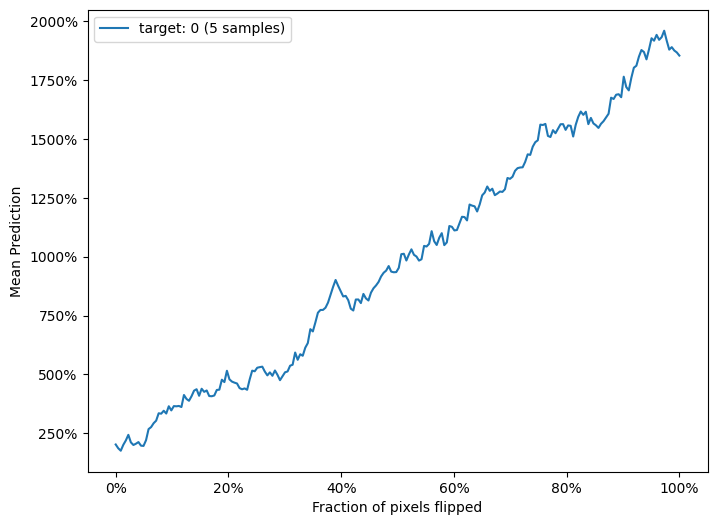

Faithfulness Scores (Pixel-Flipping): [[0.9861057996749878, 0.8598352670669556, 1.0399470329284668, 2.173035144805908, 2.2353312969207764, 1.9005144834518433, 2.0408458709716797, 1.391048550605774, 1.2172189950942993, 2.0241312980651855, 1.4000297784805298, 1.1558594703674316, 1.1720901727676392, 1.21027672290802, 1.1265571117401123, 1.6064637899398804, 0.934511125087738, 1.4593493938446045, 1.7746834754943848, 1.3118467330932617, 0.9968072772026062, 0.9391481280326843, 1.2575901746749878, 1.632023811340332, 1.682774305343628, 1.632064938545227, 1.3449190855026245, 2.813448905944824, 2.1982545852661133, 1.872827410697937, 1.7498072385787964, 2.0801010131835938, 1.968924641609192, 1.697844386100769, 1.12013840675354, 1.9901612997055054, 2.0465071201324463, 1.8952314853668213, 1.8379889726638794, 1.9654598236083984, 1.8172279596328735, 1.9225878715515137, 4.450667381286621, 4.567875385284424, 4.458655834197998, 5.057095527648926, 4.459433078765869, 4.0717692375183105, 4.0309648513793945,

In [ ]:
# 2. Faithfulness: pixel-flipping (Bach et al., 2015)
pixel_flipping = quantus.PixelFlipping(
    features_in_step=224,  # Adjust step size (smaller = smoother curve)
    perturb_baseline="uniform",
    perturb_func_kwargs={"uniform_low": 0.0, "uniform_high": 1.0},
    return_auc_per_sample=False,
    disable_warnings=True
)


scores_faithfulness = pixel_flipping(
    model=model,
    x_batch = np.array(x_batch).astype(np.float32),
    y_batch = np.zeros(len(x_batch), dtype=int),
    a_batch=a_batch,
    explain_func=None,
    softmax=False,
    model_predict_kwargs={"batch_size": 32}
)

pixel_flipping.plot(y_batch=np.zeros((x_batch.shape[0],), dtype=int), scores=scores_faithfulness)

print(f"Faithfulness Scores (Pixel-Flipping): {scores_faithfulness}")

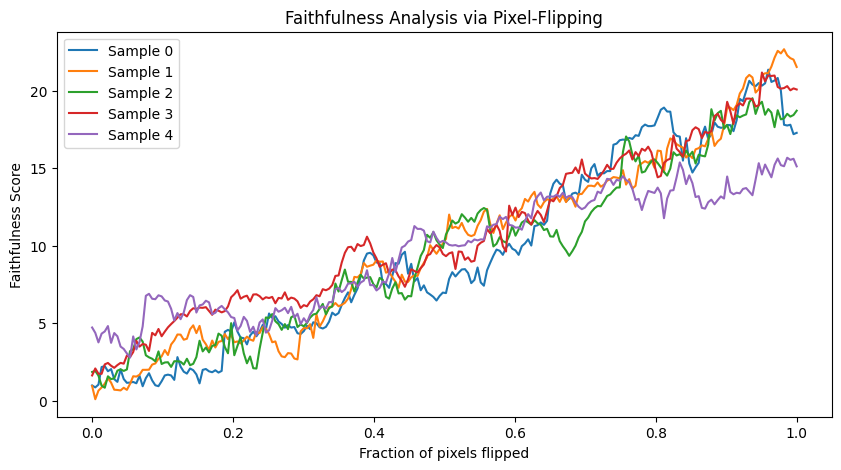

In [ ]:
plt.figure(figsize=(10, 5))
faith_m=[]
for i, scores in enumerate(scores_faithfulness):
    plt.plot(np.linspace(0, 1, len(scores)), scores, label=f"Sample {i}")
    faith_m.append(np.mean(scores))

plt.xlabel("Fraction of pixels flipped")
plt.ylabel("Faithfulness Score")
plt.title("Faithfulness Analysis via Pixel-Flipping")
plt.legend()
plt.show()

In [ ]:
x_batch = []
a_batch = []
for index, row in df.iterrows():
    image_name = row["Image"] + ".png"
    img, img_array = prep_single_image(path_to_test_img + image_name, model)
    input_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    x_batch.append(tf.squeeze(input_tensor, axis=0))
    sal_explanations = custom_explain(model, input_tensor, None)
    sal_explanations = np.squeeze(sal_explanations, axis=0)
    a_batch.append(sal_explanations)

x_batch = np.array([tensor.numpy() if isinstance(tensor, tf.Tensor) else tensor for tensor in x_batch])
x_batch = np.array(x_batch).astype(np.float32) / 255.0  # Normalize to [0, 1]
a_batch = np.array(a_batch)  # Convert attribution maps
x_batch = np.mean(x_batch, axis=-1, keepdims=True)


print("x_batch shape:", x_batch.shape)
print("a_batch shape before fix:", a_batch.shape)
if len(a_batch.shape) == 3:
    a_batch = np.expand_dims(a_batch, axis=1)

print(" a_batch shape after fix:", a_batch.shape)
def generate_slic_segments(image_batch, n_segments=100):
    s_batch = []
    for image in image_batch:
        image_np = image.numpy() if isinstance(image, tf.Tensor) else image
        segments = slic(image_np, n_segments=n_segments, compactness=10, start_label=1)
        s_batch.append(segments)
    return np.array(s_batch)

s_batch = generate_slic_segments(x_batch)  # Shape: (N, 224, 224)
s_batch = np.expand_dims(s_batch, axis=-1)  # Convert to (N, 224, 224, 1)
s_batch = np.transpose(s_batch, (0, 3, 1, 2))  # Reshape to (N, 1, H, W)

# Keep the largest 3 regions
for i in range(s_batch.shape[0]):
    mask = s_batch[i, 0]
    unique_labels, counts = np.unique(mask, return_counts=True)
    num_segments_to_keep = max(5, len(unique_labels) // 2)
    top_labels = unique_labels[np.argsort(counts)[-num_segments_to_keep:]]
    s_batch[i, 0] = np.isin(mask, top_labels).astype(np.uint8)
s_batch = (s_batch > 0).astype(np.uint8)
s_batch = s_batch.astype(bool)
assert s_batch.shape == (5, 1, 224, 224), f"Expected s_batch shape: (5, 1, 224, 224), but got {s_batch.shape}"
assert np.isin(s_batch, [0, 1]).all(), "s_batch should contain only 0 and 1 (or True/False)"
print("s_batch successfully converted to a structured binary mask.")
a_batch = a_batch / np.max(a_batch, axis=(2, 3), keepdims=True)
a_batch[a_batch < 0.5] = 0


localisation = quantus.RelevanceMassAccuracy()
x_batch = np.transpose(x_batch, (0, 3, 1, 2))  # Reshape to (N, 1, H, W)

scores_localisation = localisation(
    model=model,            # Your actual sigmoid model
    x_batch=x_batch,        # Input images (grayscale, 1 channel)
    y_batch=np.random.randint(0, 2, (5, 1)).astype(np.float32),  # Binary labels
    a_batch=a_batch,        # Attribution maps
    s_batch=s_batch,        # Boolean mask (N, 1, H, W)
    channel_first=True,     # Since we are using (N, 1, H, W)
    explain_func=None,      # No need for an explainer function
    explain_func_kwargs={},
    model_predict_kwargs={},
    softmax=False,          # Sigmoid does NOT use softmax
    device="cpu"
)

print("Relevance Mass Accuracy Scores:", scores_localisation)

x_batch shape: (5, 224, 224, 1)
a_batch shape before fix: (5, 224, 224)
 a_batch shape after fix: (5, 1, 224, 224)
s_batch successfully converted to a structured binary mask.
Relevance Mass Accuracy Scores: [0.11910352, 0.27841234, 0.2851314, 0.23757562, 0.3299868]


In [ ]:
pd.DataFrame(
    [
        comp_scores,
        scores_robustness,
        scores_localisation,
        faith_m
    ],
    index=[
        "Complexity",
        "LocalLipschitzEstimate",
        "Localisation",
        "faitfulness"
    ],
).aggregate([np.mean, np.std], axis=1)

<ipython-input-91-b5fe0d285647>:14: FutureWarning: The provided callable <function mean at 0x7cc3c417eac0> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ).aggregate([np.mean, np.std], axis=1)
<ipython-input-91-b5fe0d285647>:14: FutureWarning: The provided callable <function std at 0x7cc3c417ec00> is currently using Series.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  ).aggregate([np.mean, np.std], axis=1)


,mean,std
Complexity,9.360562,0.241967
LocalLipschitzEstimate,0.031333,0.026458
Localisation,0.250042,0.080199
faitfulness,9.931590,0.489991


### **4b II) Incompatibility issues with Quantus:**
- Model Parameter Randomisation Test (MPRT)


In [ ]:
# 4. Randomisation: model parameter randomisation test (Adebayo et al., 2018)
mprt = quantus.MPRT(**init_kwargs,
                      layer_order="bottom_up",
                      similarity_func=quantus.similarity_func.correlation_spearman,
                       )
scores_randomisation = mprt(model=model,
                        x_batch=x_batch[:1],
                        y_batch=y_predicted[:1],
                        a_batch=a_batch[:1],
                        explain_func= custom_explain,
                        )

quantus.plot_model_parameter_randomisation_experiment(results=scores_randomisation, methods=["GradCAM"], similarity_metric=quantus.similarity_func.correlation_spearman.__name__.replace("_", "").capitalize())

print(f"Randomisation Scores (model parameter randomisation): {scores_randomisation}")

  0%|          | 0/340 [00:00<?, ?it/s]

ValueError: Input 0 of layer "functional_110" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 3, 224, 224)

### **4c) Evaluating Explanation Ranking with NDCG Score**  
The **Normalized Discounted Cumulative Gain (NDCG) Score** measures how well a ranking of explanations matches an **ideal ranking** based on ground truth relevance. It is commonly used to evaluate ranking quality in tasks like **feature importance ordering or retrieval systems**.  

In [ ]:
import numpy as np
from sklearn.metrics import ndcg_score
true_list = [5.5, 5, 4.5, 4, 3.5, 3, 2.5, 2, 1.5, 1]
true_relevance = np.asarray([true_list])
print(f"True Relevance: {true_relevance}")
values_list = list(ranked_list.values())
my_dict = dict(zip(true_list, values_list))
sorted_dict_desc = dict(sorted(my_dict.items(), key=lambda item: item[1], reverse=True))
similarity_list = list(sorted_dict_desc.keys())

similarity_scores = np.asarray([similarity_list])
print(f"similarity order: {similarity_scores}")
ndcg_similarity = ndcg_score(true_relevance, similarity_scores)
print(f"NDCG of cosine similarity order: {ndcg_similarity:.4f}")

ndcg_scientist = ndcg_score(true_relevance, true_relevance)
print(f"NDCG of scientist order: {ndcg_scientist:.4f}")

print(f"NDCG of order by cosine similarity OVER NDCG of scientist order: {ndcg_similarity/ndcg_scientist}")

True Relevance: [[5.5 5.  4.5 4.  3.5 3.  2.5 2.  1.5 1. ]]
similarity order: [[5.5 3.  4.  5.  4.5 1.  1.5 3.5 2.  2.5]]
NDCG of cosine similarity order: 0.9674
NDCG of scientist order: 1.0000
NDCG of order by cosine similarity OVER NDCG of scientist order: 0.9674277311677872


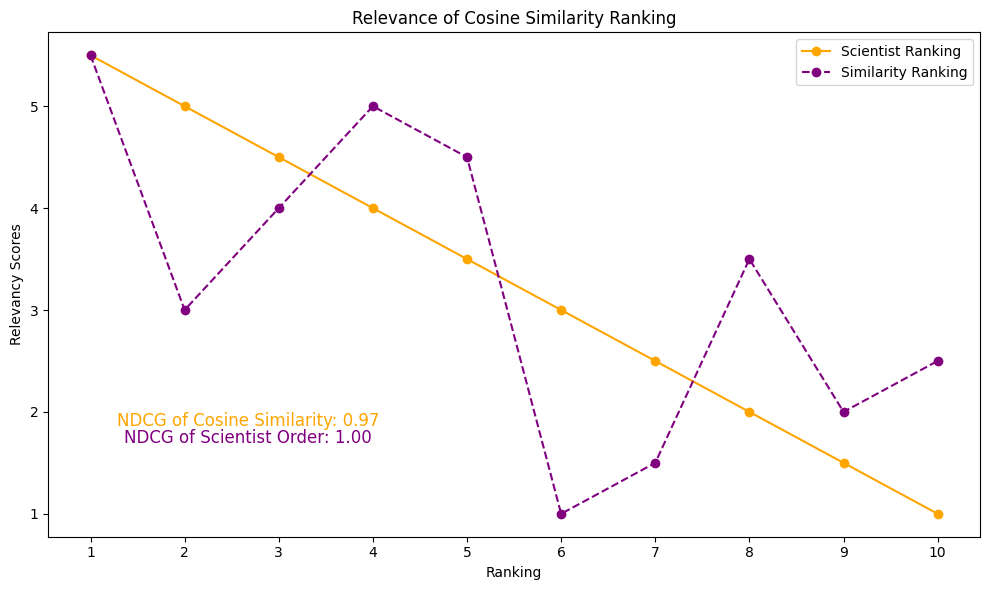

In [ ]:
# Plotting the results
fig, ax = plt.subplots(figsize=(10, 6))

# sorted_dict_desc = dict(sorted(ranked_list.items(), key=lambda item: item[1], reverse=True))
# items = list(sorted_dict_desc.keys())

# X-axis labels
items= list(range(1, len(ranked_list) + 1))
# items = list(ranked_list.keys())
ax.set_xticks(items)
# Plot true relevance, similarity order, and scientist order
ax.plot(items, true_relevance.flatten(), label="Scientist Ranking", marker='o', linestyle='-', color='orange')
ax.plot(items, similarity_scores.flatten(), label="Similarity Ranking", marker='o', linestyle='--', color='purple')

# Add titles and labels
ax.set_title("Relevance of Cosine Similarity Ranking")
ax.set_xlabel("Ranking")
ax.set_ylabel("Relevancy Scores")
ax.legend()

# Show the NDCG values as text on the plot
ax.text(2.67, 1.86, f"NDCG of Cosine Similarity: {ndcg_similarity:.2f}", fontsize=12, color='orange', ha='center')
ax.text(2.67, 1.69, f"NDCG of Scientist Order: {ndcg_scientist:.2f}", fontsize=12, color='purple', ha='center')

# Display the plot
plt.tight_layout()
plt.show()

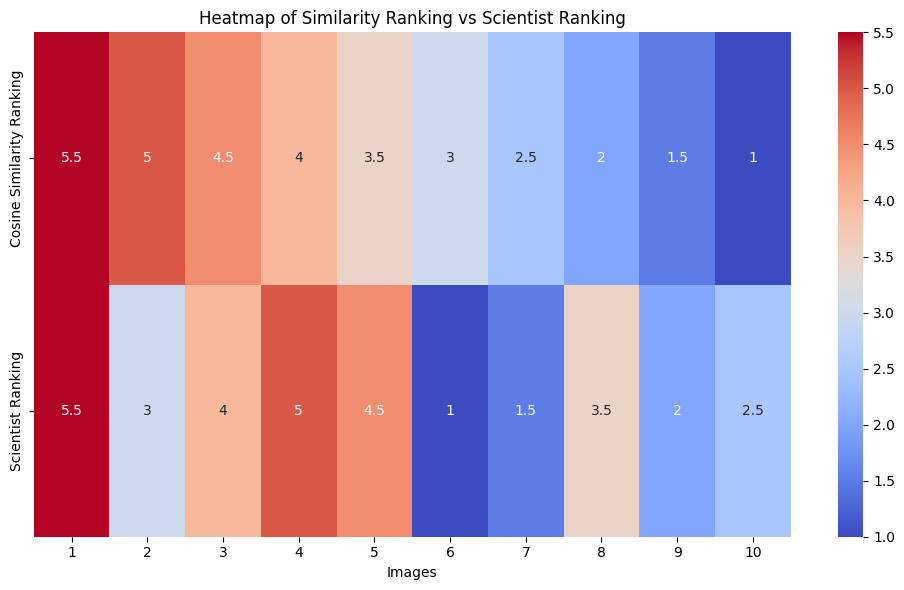

In [ ]:
import seaborn as sns

# Stack the data to make it easier for heatmap plotting
ranking_matrix = np.vstack([[true_relevance.flatten()], similarity_scores.flatten()])

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ranking_matrix, annot= True, cmap="coolwarm", xticklabels=items, yticklabels=["Cosine Similarity Ranking", "Scientist Ranking"], cbar=True)

# Add titles
plt.title("Heatmap of Similarity Ranking vs Scientist Ranking")
plt.xlabel("Images")

# Display the plot
plt.tight_layout()
plt.show()